In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import math

plt.rcParams.update({
    'font.size': 16,            # Default font size
    'axes.titlesize': 18,       # Title font size
    'axes.labelsize': 16,       # Axis label font size
    'xtick.labelsize': 14,      # X tick label font size
    'ytick.labelsize': 14,      # Y tick label font size
    'legend.fontsize': 14,      # Legend font size
})


In [77]:
# Load your CSV
df = pd.read_csv("/Users/Student/wm_inference_diffusion/src/pruned_sweep_results.csv")

# Ensure numeric conversion (to handle missing values gracefully)
for col in ["planning_steps", "threshold", "inner_steps", "mean", "std"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Baseline (reward, 0 steps, threshold=2.0, inner=0) ---
baseline_row = df[
    (df["mode"] == "reward") &
    (df["planning_steps"] == 0) &
    (df["threshold"] == 2.0) &
    (df["inner_steps"] == 0)
].iloc[0]

base_reward = baseline_row["mean"]
base_std = baseline_row["std"]


def plot_comparison(title, subset_df, x_col, xlabel):
    """
    Plot reward vs value mode for a given subset of df
    """
    plt.figure(figsize=(8, 5))
    for mode, color in [("reward", "green"), ("value", "blue")]:
        mode_df = subset_df[subset_df["mode"] == mode].dropna(subset=["mean", "std"])
        if mode_df.empty:
            continue
        x = mode_df[x_col].values
        y = mode_df["mean"].values
        yerr = mode_df["std"].values
        plt.plot(x, y, label=f"{mode.title()} Planning", color=color, marker="o")
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.2, color=color)

    # baseline line
    plt.axhline(y=base_reward, linestyle="--", color="gray", label="No Planning")
    plt.fill_between([min(subset_df[x_col]), max(subset_df[x_col])],
                     base_reward - base_std, base_reward + base_std,
                     color="gray", alpha=0.2)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Cumulative Reward")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_subset(ax, subset, x_col, xlabel, title=None, ylabel=False):
    for mode, color in [("reward", "green"), ("value", "blue")]:
        sub = subset[(subset["mode"] == mode)].dropna(subset=["mean"])
        if sub.empty:
            continue
        x = sub[x_col].values
        y = sub["mean"].values
        yerr = sub["std"].values
        ax.plot(x, y, label=f"{mode.title()} Planning", color=color, marker="o")
        ax.fill_between(x, y-yerr, y+yerr, alpha=0.2, color=color)

    # baseline line
    ax.axhline(y=base_reward, linestyle="--", color="gray", label="No Planning")
    ax.fill_between([subset[x_col].min(), subset[x_col].max()],
                    base_reward-base_std, base_reward+base_std,
                    color="gray", alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel("Cumulative Reward")  # only leftmost column
    ax.grid(True)

    # ensure yticks are visible on all subplots
    ax.tick_params(axis='y', which='both', labelleft=True)


def plot_grid(subsets, x_col, xlabel, titles=None, ncols=3):
    n = len(subsets)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), sharey=True)
    axes = axes.flatten() if n > 1 else [axes]

    for i, subset in enumerate(subsets):
        # Determine if this subplot is in the leftmost column
        col = i % ncols
        plot_subset(
            axes[i],
            subset,
            x_col,
            xlabel,
            title=titles[i] if titles else "",
            ylabel=(col == 0)  # only leftmost column gets ylabel
        )

    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center", ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout()
    plt.show()

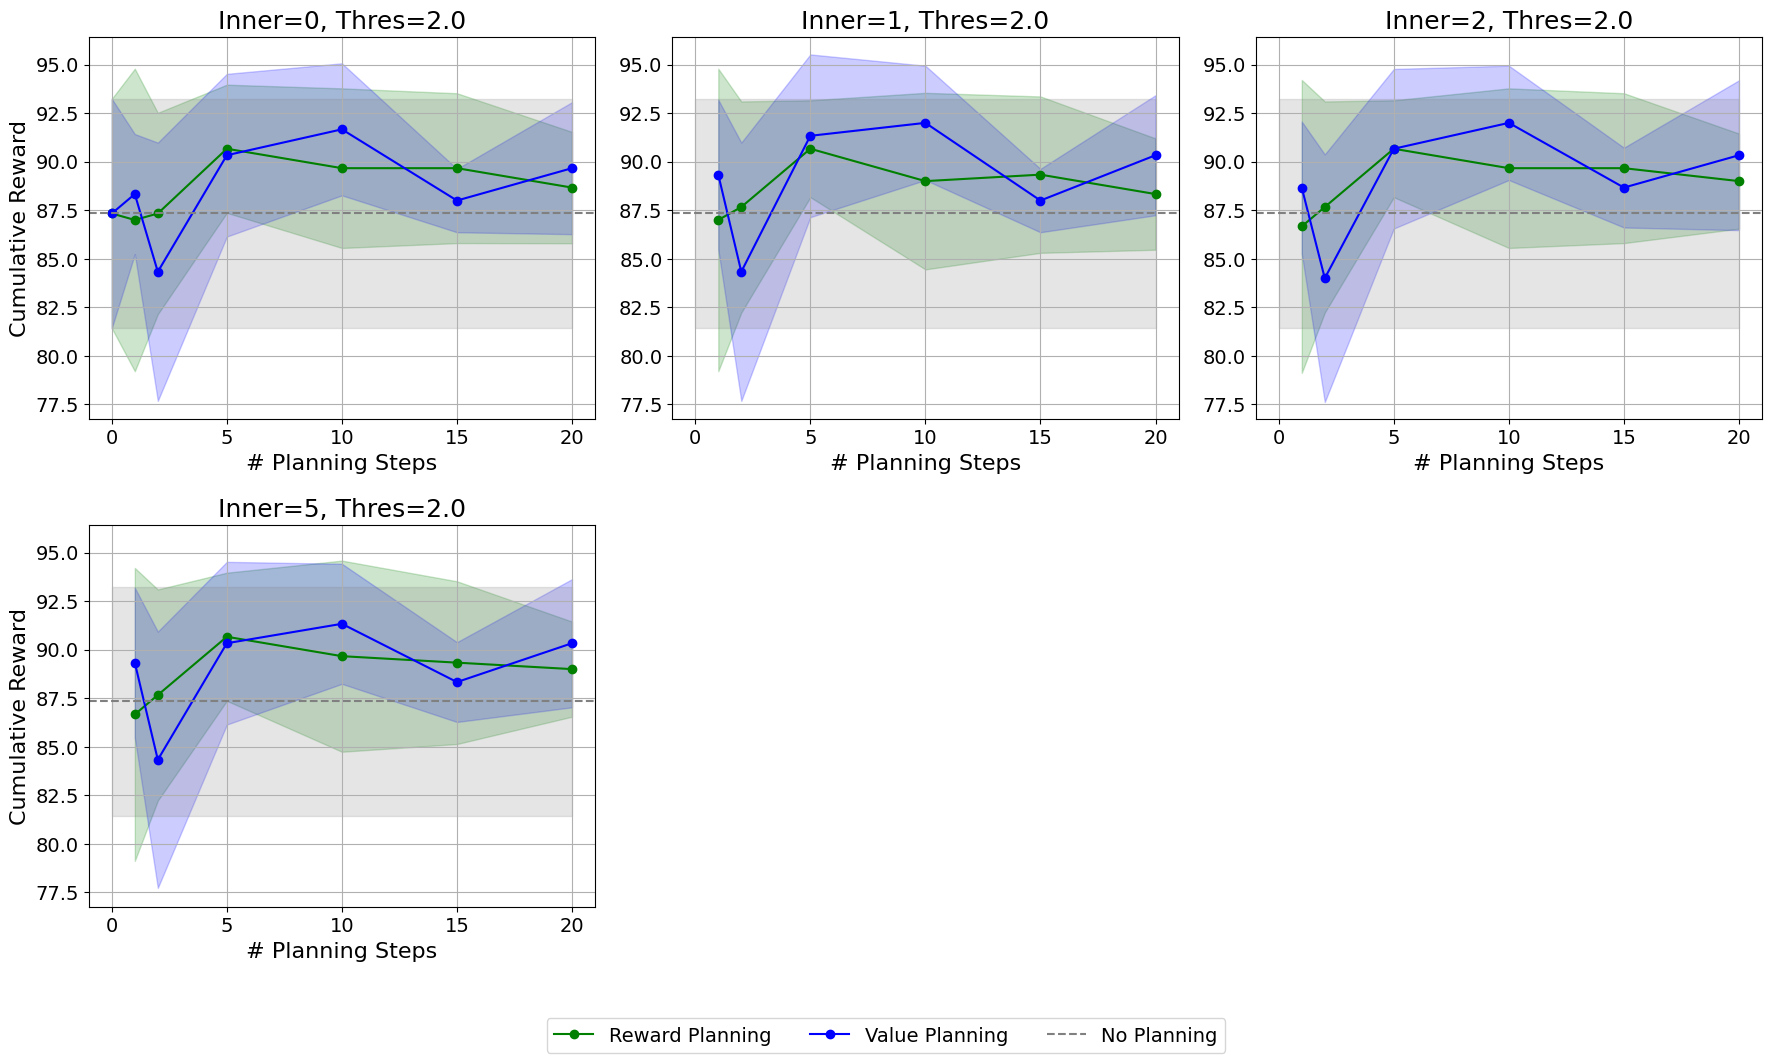

In [78]:
subsets = [
    df[(df["threshold"]==2.0) & (df["inner_steps"]==inner)]
    for inner in [0,1,2,5]
]
titles = [f"Inner={i}, Thres=2.0" for i in [0,1,2,5]]
plot_grid(subsets, "planning_steps", "# Planning Steps", titles=titles)

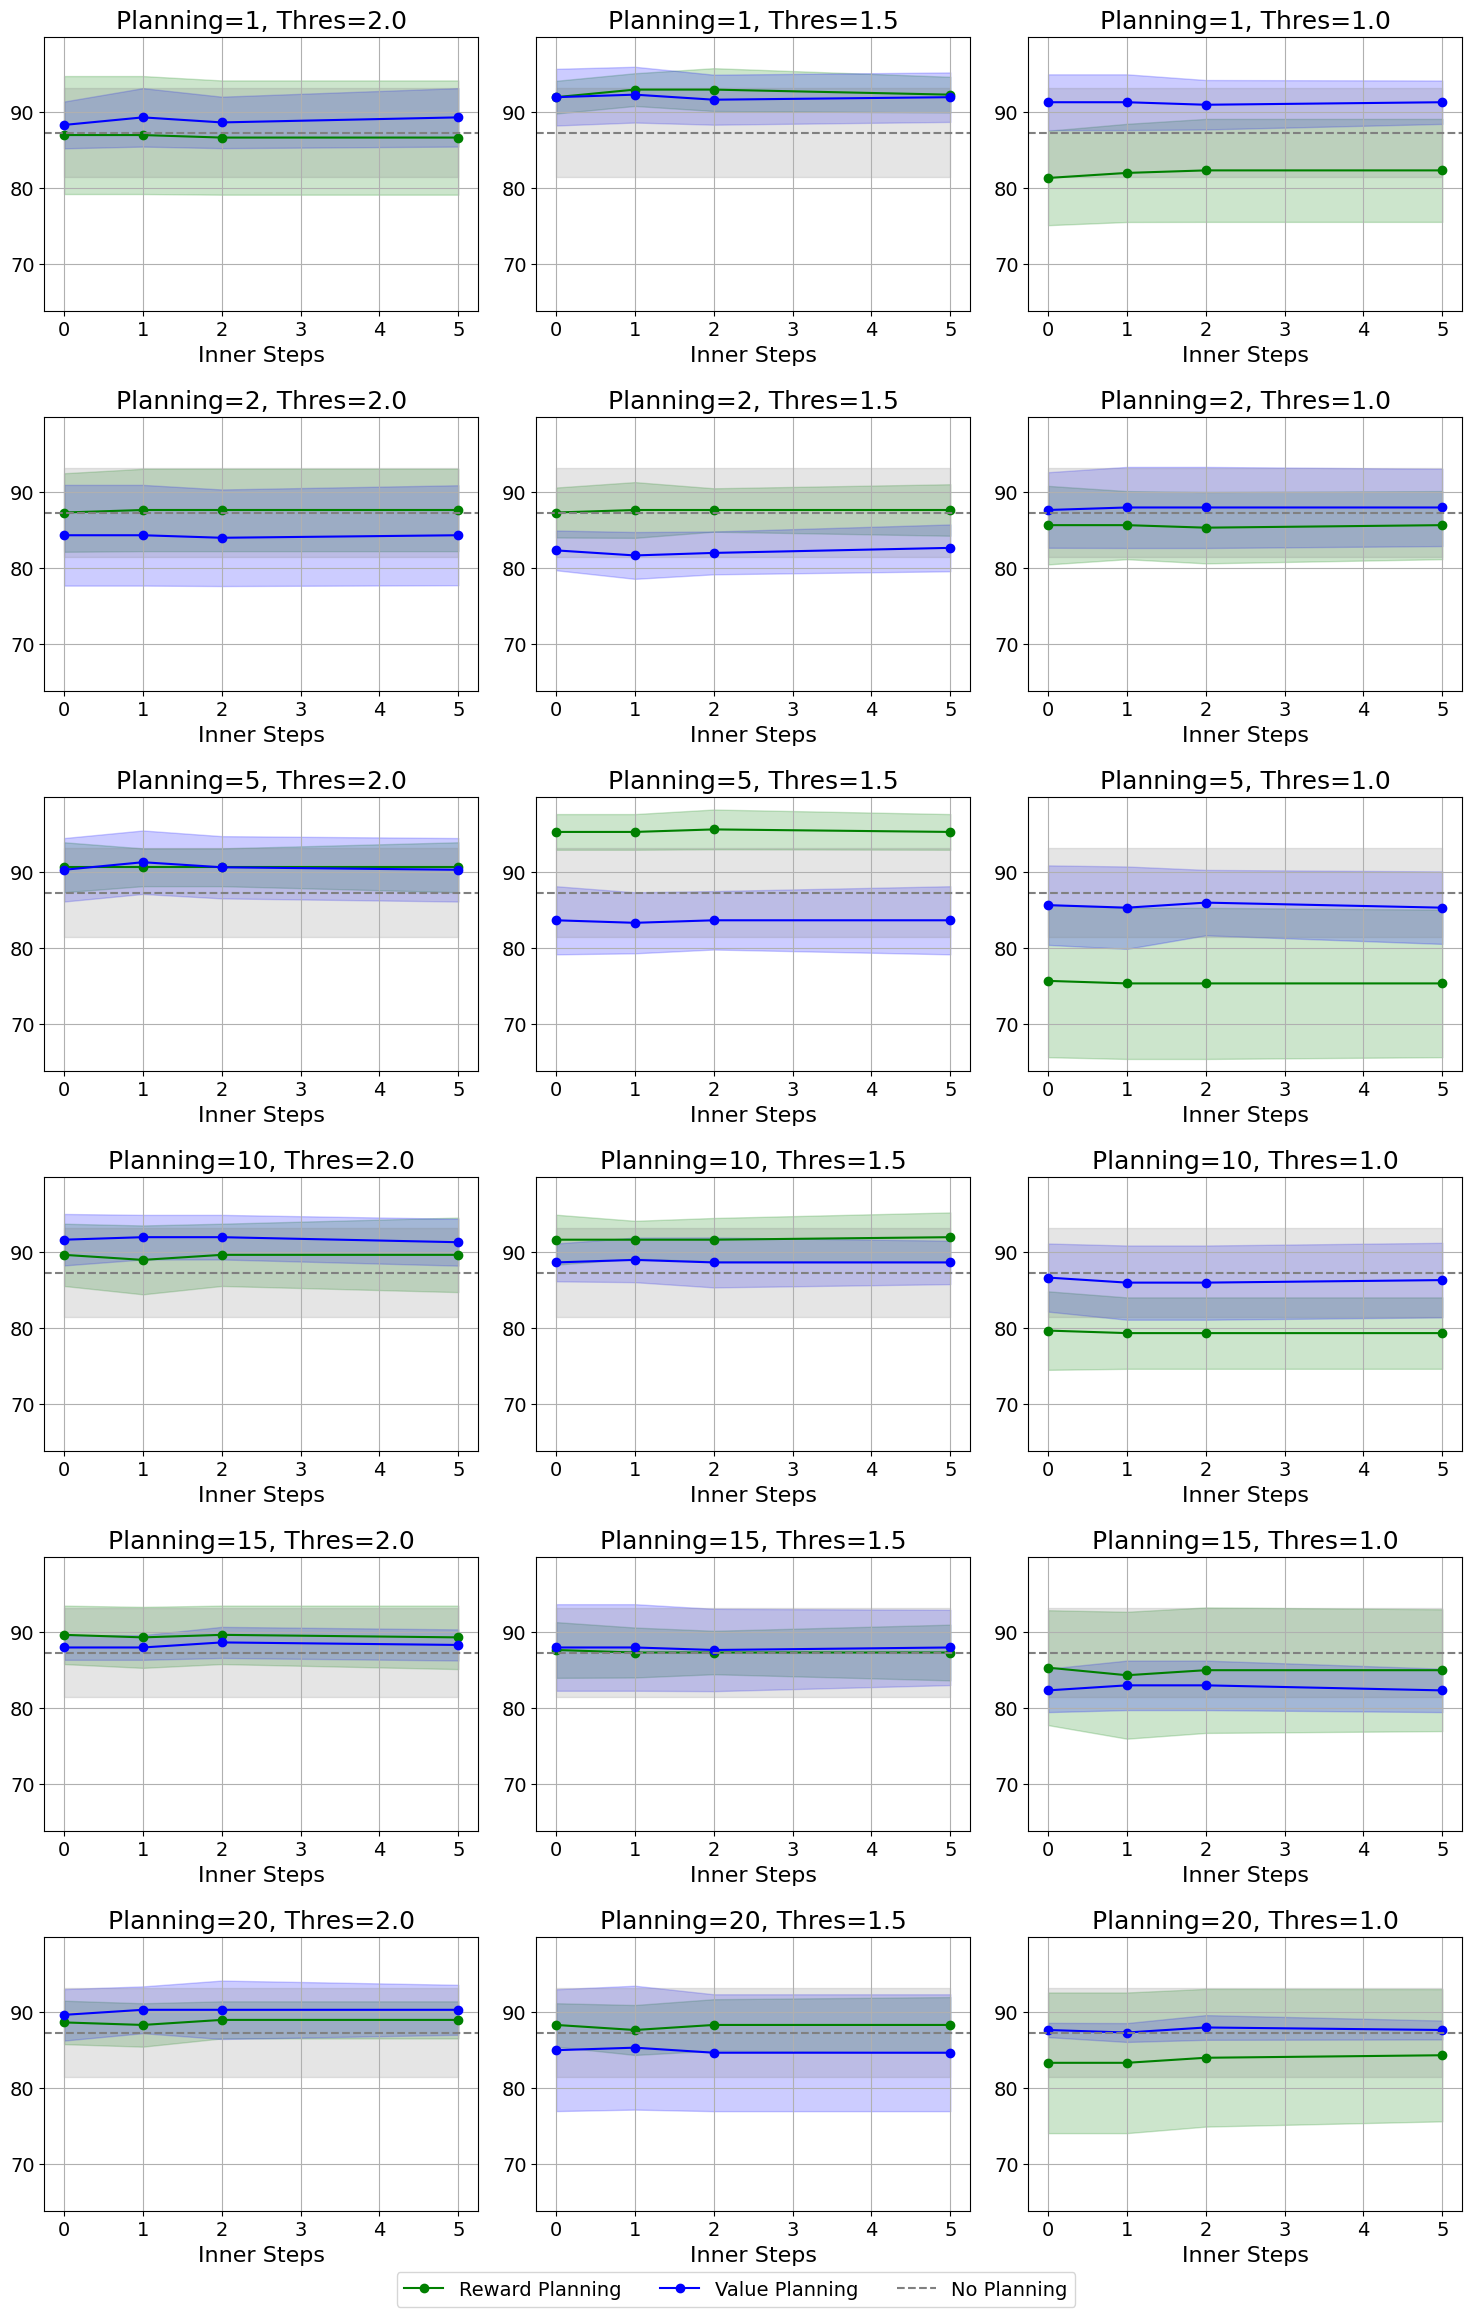

In [79]:
planning_vals = [1, 2, 5, 10, 15, 20]
thresholds = [2.0, 1.5, 1.0]

# Build subsets and titles
subsets = []
titles = []
for p in planning_vals:
    for thr in thresholds:
        subsets.append(df[(df["planning_steps"] == p) & (df["threshold"] == thr)])
        titles.append(f"Planning={p}, Thres={thr}")

# Plot in grid: rows = planning_vals, cols = thresholds
nrows = len(planning_vals)
ncols = len(thresholds)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows), sharey=True)

for i, (subset, title) in enumerate(zip(subsets, titles)):
    r, c = divmod(i, ncols)
    plot_subset(
        axes[r, c],
        subset,
        x_col="inner_steps",
        xlabel="Inner Steps",
        title=title
    )

# Shared legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center", ncol=3, bbox_to_anchor=(0.5, 0))

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

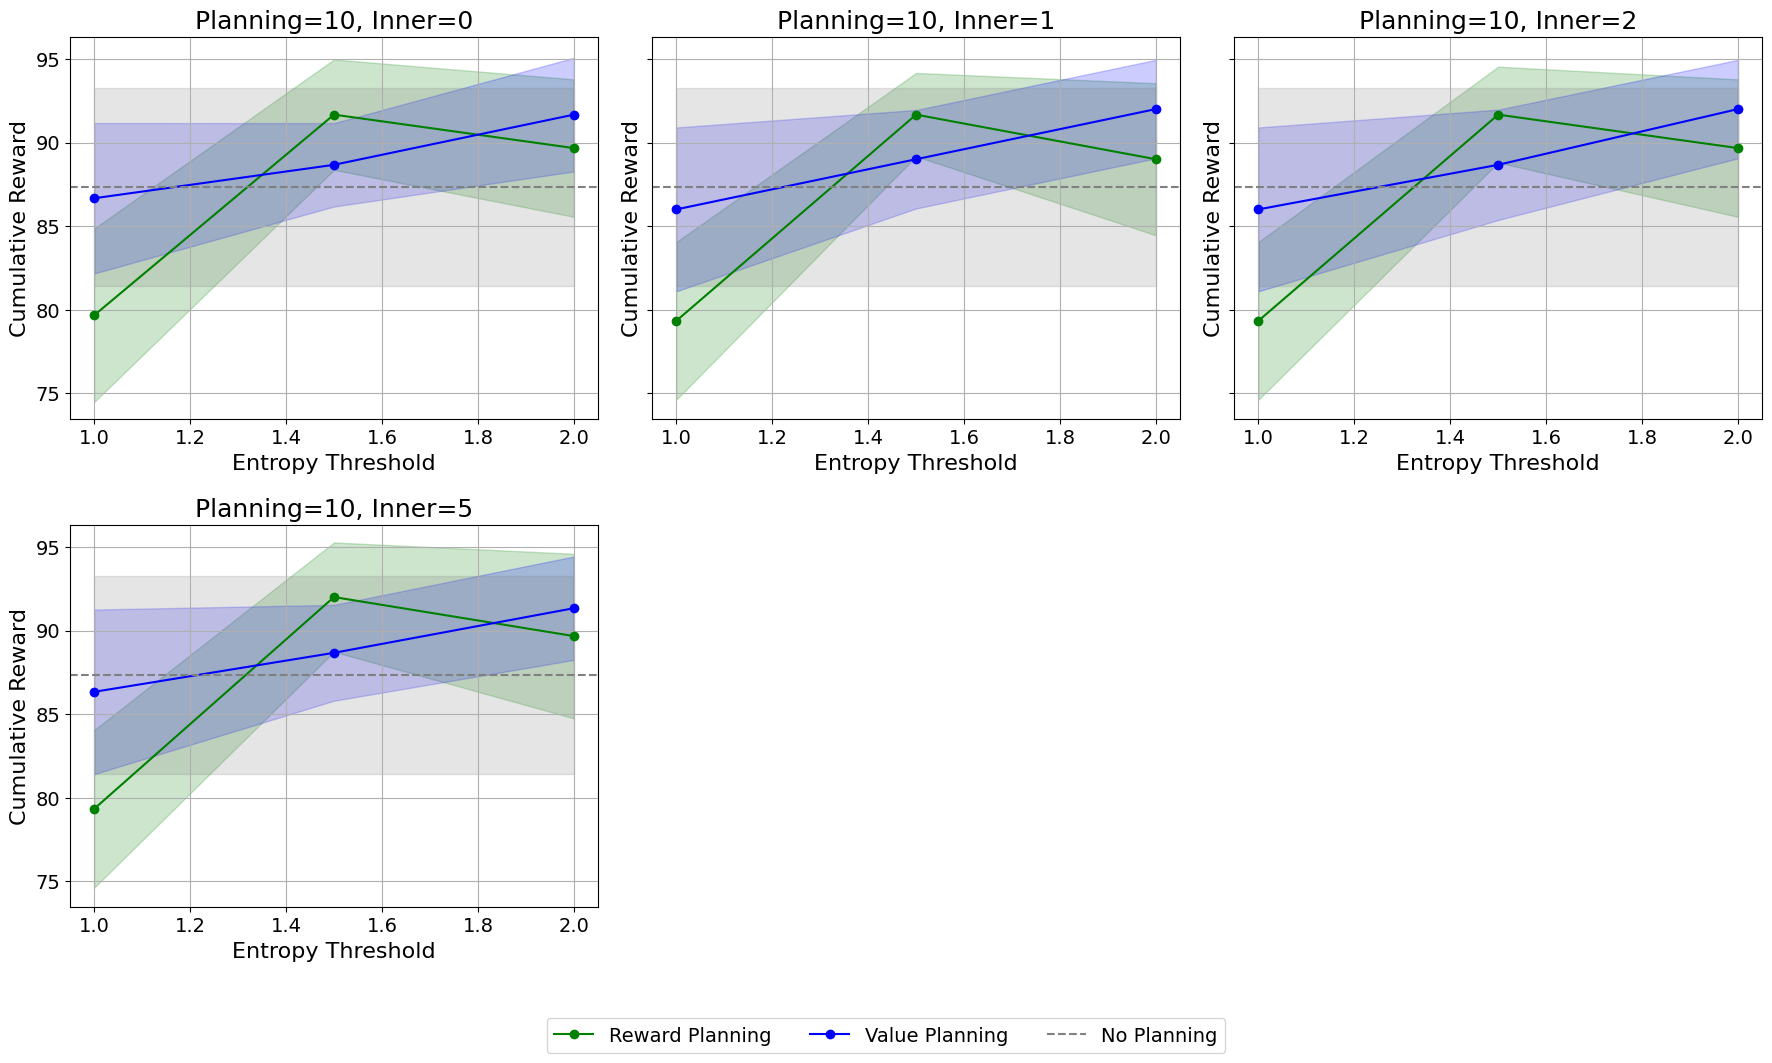

In [65]:
subsets = [
    df[(df["planning_steps"]==10) & (df["inner_steps"]==inner)]
    for inner in [0,1,2,5]
]
titles = [f"Planning=10, Inner={i}" for i in [0,1,2,5]]
plot_grid(subsets, "threshold", "Entropy Threshold", titles)

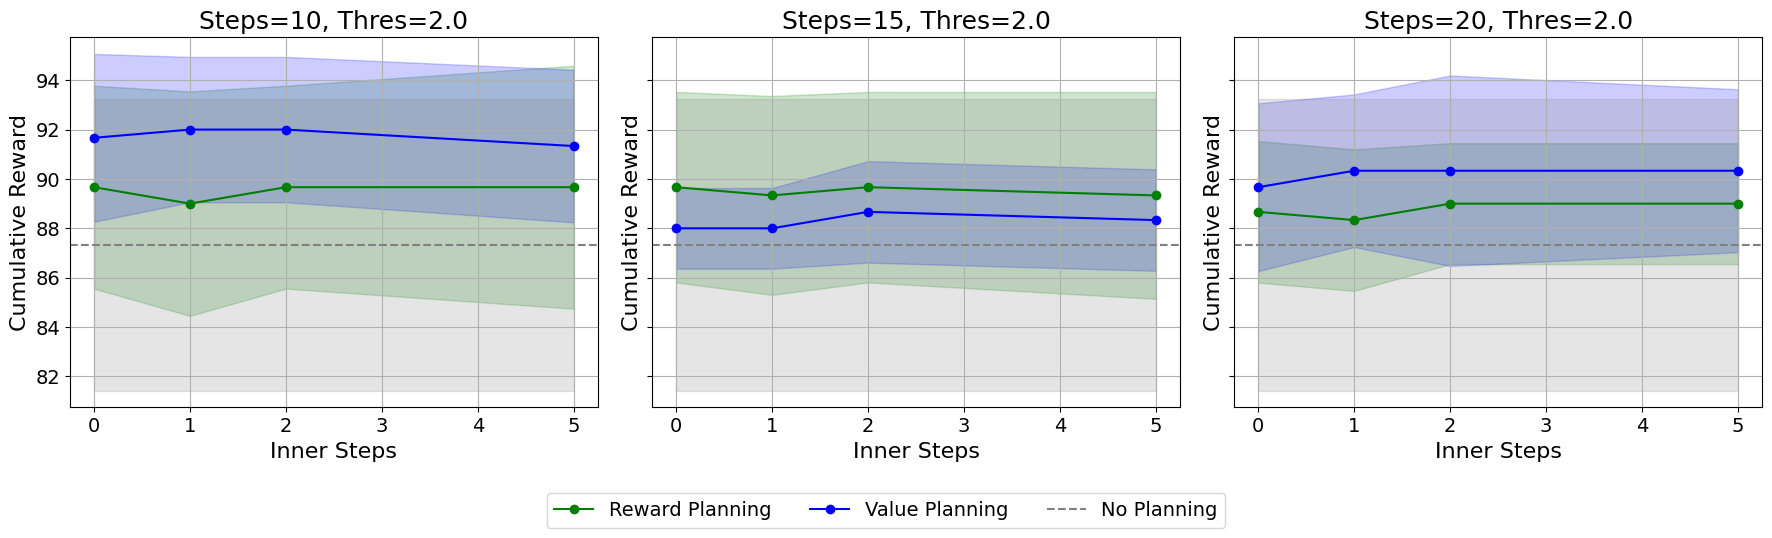

In [67]:
subsets = [
    df[(df["planning_steps"]==ps) & (df["threshold"]==2.0)]
    for ps in [10,15,20]
]
titles = [f"Steps={ps}, Thres=2.0" for ps in [10,15,20]]
plot_grid(subsets, "inner_steps", "Inner Steps", titles)